In [ ]:
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image

In [ ]:
model= Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(224,224,3)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(128,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))


model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss=keras.losses.binary_crossentropy,optimizer='Adam',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 222, 222, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 220, 220, 64)      18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 110, 110, 64)      0         
_________________________________________________________________
dropout (Dropout)            (None, 110, 110, 64)      0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 108, 108, 64)      36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 54, 54, 64)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 54, 54, 64)        0

In [ ]:
train_datagen=image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,

)
test_dataset=image.ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator=train_datagen.flow_from_directory(
    '/content/drive/MyDrive/new_data_set_with_testing/Train',
    target_size=(224,224),
    batch_size=16,
    class_mode='binary'
)


Found 224 images belonging to 2 classes.


In [ ]:
validation_generator=train_datagen.flow_from_directory(
    '/content/drive/MyDrive/new_data_set_with_testing/Val',
    target_size=(224,224),
    batch_size=16,
    class_mode='binary'
)

Found 30 images belonging to 2 classes.


In [ ]:
history=model.fit_generator(
    train_generator,
    steps_per_epoch=2,
    epochs=100,
    validation_data=validation_generator,
    validation_steps=2
)

/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training.py:1844: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  warnings.warn('`Model.fit_generator` is deprecated and '


Epoch 1/100
2/2 [==============================] - 20s 10s/step - loss: 1.4260 - accuracy: 0.5208 - val_loss: 0.7420 - val_accuracy: 0.5000
Epoch 2/100
2/2 [==============================] - 7s 4s/step - loss: 1.6498 - accuracy: 0.5417 - val_loss: 0.6869 - val_accuracy: 0.7000
Epoch 3/100
2/2 [==============================] - 6s 3s/step - loss: 0.6976 - accuracy: 0.5833 - val_loss: 0.6816 - val_accuracy: 0.7000
Epoch 4/100
2/2 [==============================] - 6s 3s/step - loss: 0.6751 - accuracy: 0.5833 - val_loss: 0.6746 - val_accuracy: 0.8333
Epoch 5/100
2/2 [==============================] - 5s 3s/step - loss: 0.6937 - accuracy: 0.4792 - val_loss: 0.6773 - val_accuracy: 0.5333
Epoch 6/100
2/2 [==============================] - 4s 3s/step - loss: 0.6611 - accuracy: 0.6667 - val_loss: 0.6618 - val_accuracy: 0.9667
Epoch 7/100
2/2 [==============================] - 4s 3s/step - loss: 0.6251 - accuracy: 0.6667 - val_loss: 0.6324 - val_accuracy: 0.9333
Epoch 8/100
2/2 [===============

In [ ]:
history.history.keys()


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

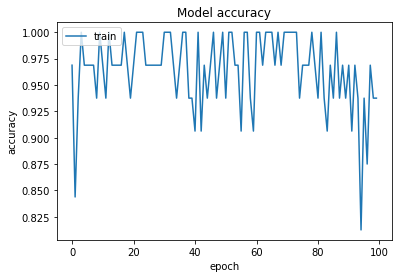

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train'],loc='upper left')
plt.show()

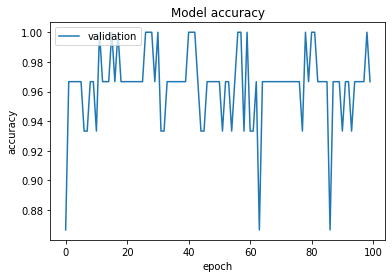

In [ ]:
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['validation'],loc='upper left')
plt.show()

In [ ]:
import os
y_actual=[]
y_test=[]

In [ ]:
for i in os.listdir("/content/drive/MyDrive/new_data_set_with_testing/Val/Normal/"):
  img=image.load_img("/content/drive/MyDrive/new_data_set_with_testing/Val/Normal/"+i,target_size=(224,224))
  img=image.img_to_array(img)
  img=np.expand_dims(img,axis=0)
  p=(model.predict(img) > 0.5).astype("int32")
  y_test.append(p[0,0])
  y_actual.append(1)

In [ ]:
for i in os.listdir("/content/drive/MyDrive/new_data_set_with_testing/Val/Covid/"):
  img=image.load_img("/content/drive/MyDrive/new_data_set_with_testing/Val/Covid/"+i,target_size=(224,224))
  img=image.img_to_array(img)
  img=np.expand_dims(img,axis=0)
  p=(model.predict(img)>0.5).astype("int32")
  y_test.append(p[0,0])
  y_actual.append(0)


In [ ]:
y_actual=np.array(y_actual)
y_test=np.array(y_test)



In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm=confusion_matrix(y_actual,y_test)

In [ ]:
import seaborn as sns

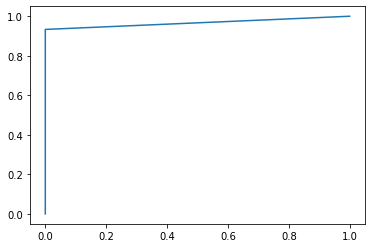

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



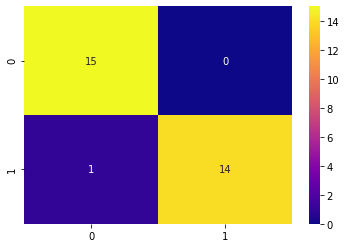

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
fpr, tpr, thresholds=roc_curve(y_actual,y_test)
plt.figure()
plt.plot(fpr,tpr)
plt.show()
sns.heatmap(cm,cmap="plasma",annot=True)
print(classification_report(y_actual,y_test))



In [ ]:
model.evaluate_generator(train_generator)

/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training.py:1877: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  warnings.warn('`Model.evaluate_generator` is deprecated and '


[0.10064710676670074, 0.9732142686843872]

In [ ]:
model.evaluate_generator(validation_generator)

/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/engine/training.py:1877: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  warnings.warn('`Model.evaluate_generator` is deprecated and '


[0.09056597203016281, 1.0]

In [ ]:
model.save('covid_final.h5/content/drive/MyDrive')

INFO:tensorflow:Assets written to: covid_final.h5/content/drive/MyDrive/assets


In [ ]:
model.save('project-final.model')

INFO:tensorflow:Assets written to: project-final.model/assets


In [ ]:
CATEGORIES=["COVID19","Normal"]

In [ ]:
import tensorflow as tf
model=tf.keras.models.load_model("project-final.model")

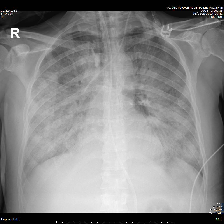

COVID19


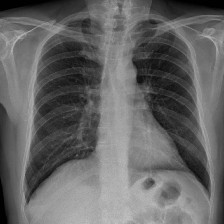

COVID19


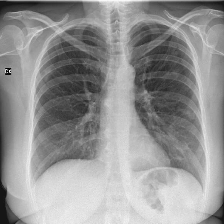

COVID19


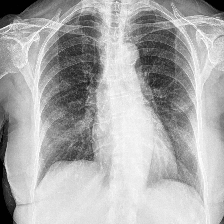

COVID19


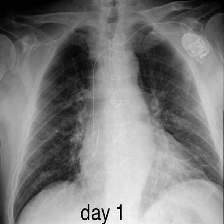

COVID19


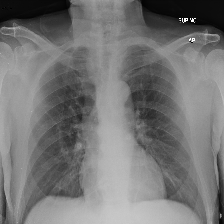

COVID19


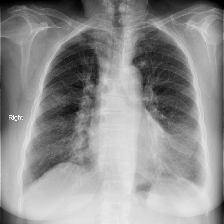

COVID19


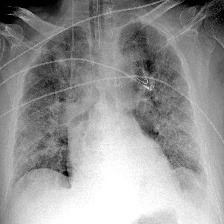

COVID19


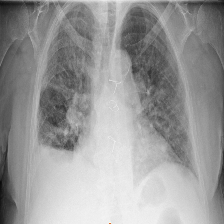

COVID19


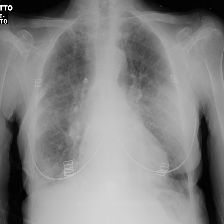

COVID19


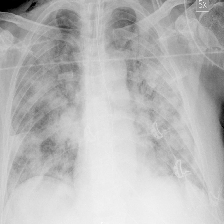

COVID19


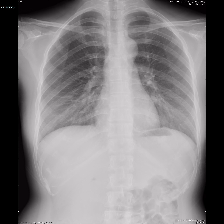

COVID19


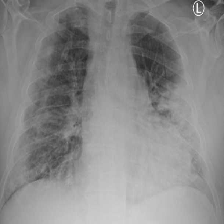

COVID19


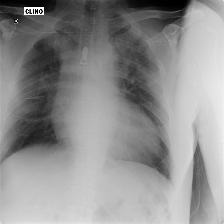

COVID19


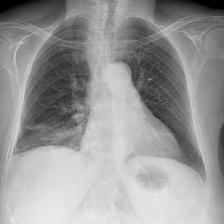

COVID19


In [ ]:
from google.colab.patches import cv2_imshow
#testing for COVID-19 images
for i in os.listdir("/content/drive/MyDrive/new_data_set_with_testing/Testing/COVID/"):
  img=image.load_img("/content/drive/MyDrive/new_data_set_with_testing/Testing/COVID/"+i,target_size=(224,224))
  img=image.img_to_array(img)
  cv2_imshow(img)
  img=np.expand_dims(img,axis=0)
  prediction=model.predict(img)
  print(CATEGORIES[int (prediction[0][0])])



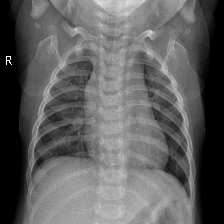

Normal


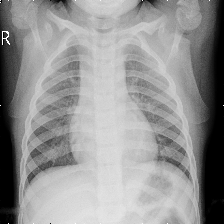

Normal


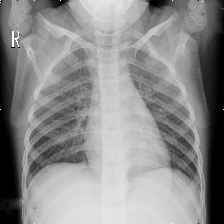

Normal


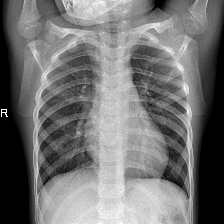

Normal


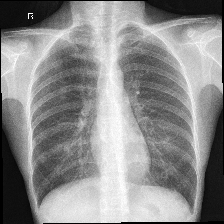

COVID19


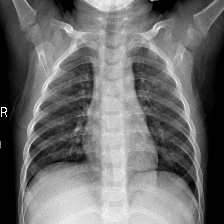

Normal


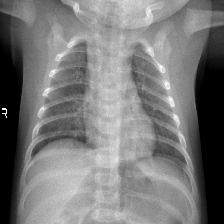

Normal


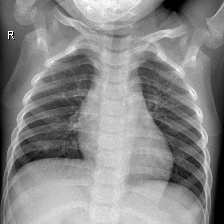

Normal


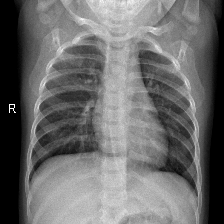

Normal


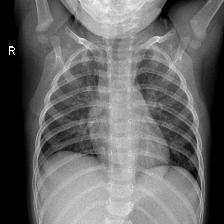

Normal


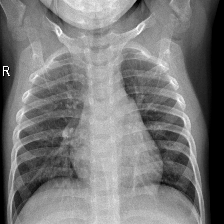

Normal


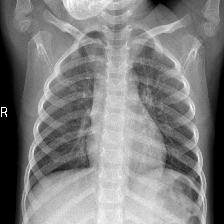

Normal


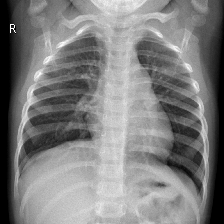

Normal


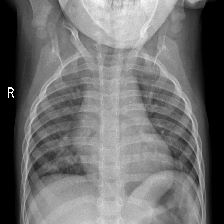

Normal


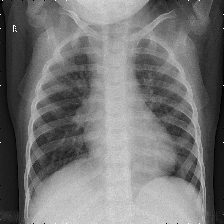

Normal


In [ ]:
#testing for normal images
for i in os.listdir("/content/drive/MyDrive/new_data_set_with_testing/Testing/Normal/"):
  img=image.load_img("/content/drive/MyDrive/new_data_set_with_testing/Testing/Normal/"+i,target_size=(224,224))
  img=image.img_to_array(img)
  cv2_imshow(img)
  img=np.expand_dims(img,axis=0)
  prediction=model.predict(img)
  print(CATEGORIES[int (prediction[0][0])])


In [ ]:
 y_actual=[]
y_test=[]

In [ ]:
for i in os.listdir("/content/drive/MyDrive/new_data_set_with_testing/Testing/Normal/"):
  img=image.load_img("/content/drive/MyDrive/new_data_set_with_testing/Testing/Normal/"+i,target_size=(224,224))
  img=image.img_to_array(img)
  img=np.expand_dims(img,axis=0)
  p=(model.predict(img) > 0.5).astype("int32")
  y_test.append(p[0,0])
  y_actual.append(1)
print(y_test)

[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
for i in os.listdir("/content/drive/MyDrive/new_data_set_with_testing/Testing/COVID/"):
  img=image.load_img("//content/drive/MyDrive/new_data_set_with_testing/Testing/COVID/"+i,target_size=(224,224))
  img=image.img_to_array(img)
  img=np.expand_dims(img,axis=0)
  p=(model.predict(img)>0.5).astype("int32")
  y_test.append(p[0,0])
  y_actual.append(0)
print(y_test)

[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
y_actual=np.array(y_actual)
y_test=np.array(y_test)



In [ ]:
cm=confusion_matrix(y_actual,y_test)

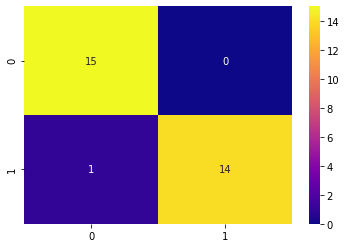

In [ ]:
sns.heatmap(cm,cmap="plasma",annot=True)